In [8]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.font_manager import FontProperties # 新增这行
from matplotlib.ticker import MultipleLocator

font_path = '/home/lgx/文档/simsun.ttc'

In [9]:
# ==========================================
# 模块 1: 数据提取 (与绘图解耦，方便复用)
# ==========================================
def load_dataset_trajectories(file_path):
    """
    从 hdf5 数据集中提取点云和所有轨迹数据。
    返回:
        pc_data: np.ndarray, (N, 3) 第一帧的点云数据
        trajectories: list of np.ndarray, 包含所有demo的轨迹点 (T, 3)
    """
    trajectories = []
    
    with h5py.File(file_path, 'r') as f:
        demos = list(f['data'].keys())
        demos.sort(key=lambda x: int(x.split('_')[1]))
        
        # 提取第一个 demo 的第一帧点云作为场景上下文
        first_demo = demos[0]
        pc_data = f[f'data/{first_demo}/obs/pointcloud'][0]
        
        # 提取所有 demo 的 EEF 轨迹
        for demo in demos:
            pos_data = f[f'data/{demo}/obs/robot0_eef_pos'][:]
            trajectories.append(pos_data)
            
    return pc_data, trajectories

In [10]:
# ==========================================
# 模块 2: 学术级绘图 (高复用性，可配置)
# ==========================================
def plot_academic_3d_trajectories_wide_cn(pc_data, trajectories, save_path=None):
    cm_to_inch = 1 / 2.54
    fig_width = 9 * cm_to_inch  
    fig_height = 8.5 * cm_to_inch  
    
    # 策略 1: 全局只设 Times New Roman
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"], 
        "axes.unicode_minus": False, 
        "mathtext.fontset": "stix",  
        "font.size": 10.5,           
        "axes.labelsize": 10.5,      
        "xtick.labelsize": 10.5,
        "ytick.labelsize": 10.5,
        "axes.linewidth": 1.0
    })
    
    cn_font = FontProperties(fname=font_path, size=10.5)
    
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=300)
    ax = fig.add_subplot(111, projection='3d')
    
    # 1. 绘制点云
    ax.scatter(pc_data[:, 0], pc_data[:, 1], pc_data[:, 2], 
               s=2, alpha=0.5, c='#B0B0B0', edgecolors='none', label='工作空间点云')

    # 2. 绘制轨迹与起点
    traj_color = '#1f77b4' 
    for i, traj in enumerate(trajectories):
        label_traj = '专家示教轨迹' if i == 0 else None
        ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], 
                color=traj_color, alpha=0.4, linewidth=0.8, label=label_traj)
        
        label_start = '轨迹起点' if i == 0 else None
        ax.scatter(traj[0, 0], traj[0, 1], traj[0, 2], 
                   color='#d62728', s=8, alpha=0.7, marker='o', label=label_start)

    # ==========================================
    # 【核心修改区】: 强制 0.1m 间距与真实物理比例
    # ==========================================
    # A. 强制每个轴的刻度间隔为 0.1
    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.zaxis.set_major_locator(MultipleLocator(0.1))
    
    # B. 提取所有点以计算 X, Y, Z 的真实物理跨度
    all_x = np.concatenate([pc_data[:, 0]] + [t[:, 0] for t in trajectories])
    all_y = np.concatenate([pc_data[:, 1]] + [t[:, 1] for t in trajectories])
    all_z = np.concatenate([pc_data[:, 2]] + [t[:, 2] for t in trajectories])
    
    range_x = all_x.max() - all_x.min()
    range_y = all_y.max() - all_y.min()
    range_z = all_z.max() - all_z.min()
    
    # C. 按照真实跨度设置 3D 框的长宽比，防止空间形变
    ax.set_box_aspect([range_x, range_y, range_z])

    # ==========================================
    # 标签与图例设置
    # ==========================================
    ax.set_xlabel(r'$\mathrm{X}$轴 ($\mathrm{m}$)', fontproperties=cn_font, labelpad=5)
    ax.set_ylabel(r'$\mathrm{Y}$轴 ($\mathrm{m}$)', fontproperties=cn_font, labelpad=5)
    ax.set_zlabel(r'$\mathrm{Z}$轴 ($\mathrm{m}$)', fontproperties=cn_font, labelpad=8) 
    
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    
    ax.xaxis._axinfo["grid"].update({"color": "#E0E0E0", "linewidth": 0.5})
    ax.yaxis._axinfo["grid"].update({"color": "#E0E0E0", "linewidth": 0.5})
    ax.zaxis._axinfo["grid"].update({"color": "#E0E0E0", "linewidth": 0.5})

    # 图例排布在左上角，上下排列
    ax.legend(loc='upper left', bbox_to_anchor=(0.0, 1.05), 
              ncol=1, frameon=False, handletextpad=0.5, prop=cn_font)

    ax.view_init(elev=20, azim=-75) 
    fig.subplots_adjust(left=0.0, right=0.85, bottom=0.1, top=0.95)

    if save_path:
        plt.savefig(save_path, dpi=300, format='pdf') 
        print(f"宽版图表已保存至: {save_path}")
    
    plt.show()

Loading data...
Plotting academic figure...
宽版图表已保存至: dataset_trajectories_academic.pdf


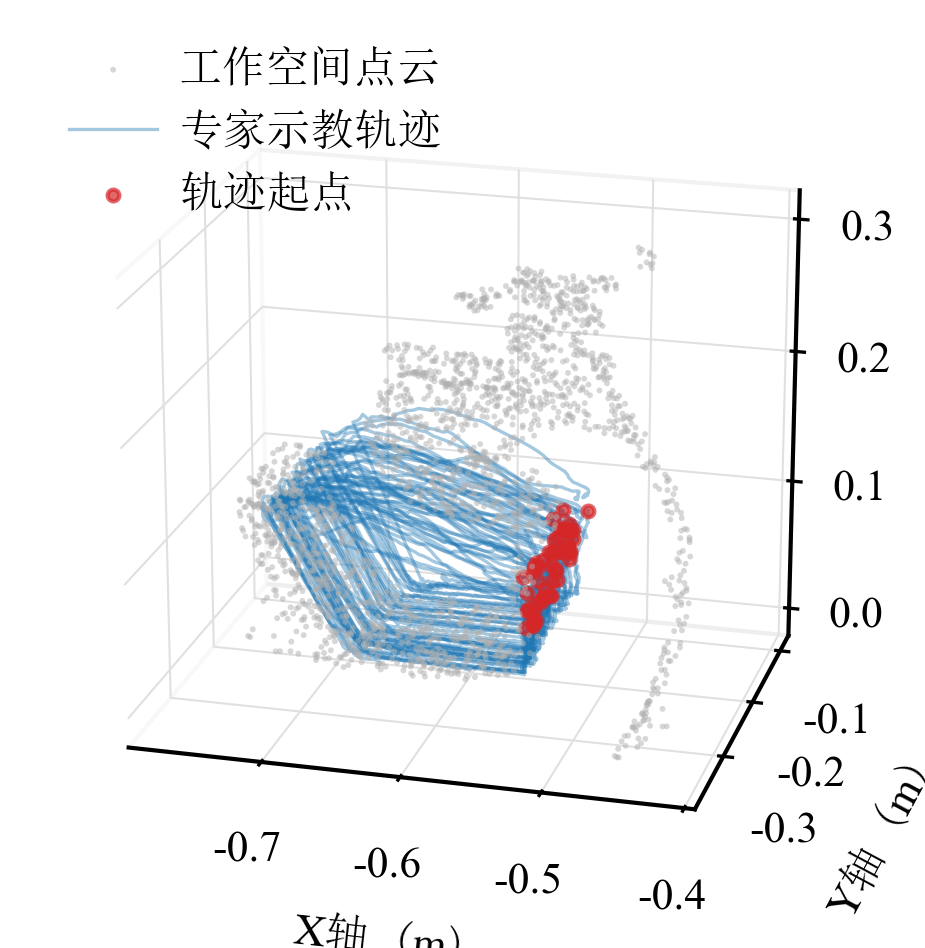

In [11]:
# ==========================================
# 运行示例
# ==========================================
if __name__ == "__main__":
    file_path = '/home/lgx/Project/AFP/src/il_capture/data/120_all_corrected_cleaned.hdf5'
    
    # 1. 获取数据 (这部分代码可以在其他地方复用)
    print("Loading data...")
    pc_data, trajectories = load_dataset_trajectories(file_path)
    
    # 2. 绘制并保存用于论文的图 (可以保存为 .pdf 或 .png)
    print("Plotting academic figure...")
    save_path = "dataset_trajectories_academic.pdf" 
    plot_academic_3d_trajectories_wide_cn(pc_data, trajectories, save_path=save_path)

In [12]:
def load_dataset_combined(file_path):
    trajectories = []
    forces = [] # 新增：存放力数据
    
    with h5py.File(file_path, 'r') as f:
        demos = list(f['data'].keys())
        demos.sort(key=lambda x: int(x.split('_')[1]))
        
        first_demo = demos[0]
        pc_data = f[f'data/{first_demo}/obs/pointcloud'][0]
        
        for demo in demos:
            # 提取轨迹
            pos_data = f[f'data/{demo}/obs/robot0_eef_pos'][:]
            trajectories.append(pos_data)
            
            # 提取力数据 (【注意】请确认你 HDF5 文件中力的键名是否为 robot0_eef_force)
            # 如果是扳手数据包含力矩，可能叫 robot0_wrench，取前三列即可
            force_data = f[f'data/{demo}/obs/robot0_eef_wrench'][:, :3]
            forces.append(force_data)
            
    return pc_data, trajectories, forces

In [13]:
def plot_academic_1x2_combined(pc_data, trajectories, forces, save_path=None):
    # 论文大图宽度 15.6 cm, 因为是双图并排，高度可以稍微压低到 6.5 cm
    cm_to_inch = 1 / 2.54
    fig_width = 15.6 * cm_to_inch  
    fig_height = 8 * cm_to_inch  
    
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"], 
        "axes.unicode_minus": False, 
        "mathtext.fontset": "stix",  
        "font.size": 10.5,           
        "axes.labelsize": 10.5,      
        "xtick.labelsize": 10.5,
        "ytick.labelsize": 10.5,
        "axes.linewidth": 1.0
    })
    
    cn_font = FontProperties(fname=font_path, size=10.5)
    
    # ==========================================
    # 创建 1行2列 的画布
    # ==========================================
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=300)
    grid = fig.add_gridspec(1, 2, width_ratios=[1.3, 1.0], wspace=0.35)
    
    # ==========================================
    # 左图 (ax1): 3D 轨迹与点云
    # ==========================================
    ax1 = fig.add_subplot(grid[0, 0], projection='3d')
    
    # 画点云
    ax1.scatter(pc_data[:, 0], pc_data[:, 1], pc_data[:, 2], 
                s=2, alpha=0.5, c='#B0B0B0', edgecolors='none', label='工作空间点云')

    # 画轨迹
    traj_color = '#1f77b4' 
    for i, traj in enumerate(trajectories):
        label_traj = '专家示教轨迹' if i == 0 else None
        ax1.plot(traj[:, 0], traj[:, 1], traj[:, 2], 
                 color=traj_color, alpha=0.3, linewidth=0.8, label=label_traj)
        
        label_start = '轨迹起点' if i == 0 else None
        ax1.scatter(traj[0, 0], traj[0, 1], traj[0, 2], 
                    color='#d62728', s=8, alpha=0.7, marker='o', label=label_start)

    # 刻度和比例设置
    ax1.xaxis.set_major_locator(MultipleLocator(0.1))
    ax1.yaxis.set_major_locator(MultipleLocator(0.1))
    ax1.zaxis.set_major_locator(MultipleLocator(0.1))
    
    all_x = np.concatenate([pc_data[:, 0]] + [t[:, 0] for t in trajectories])
    all_y = np.concatenate([pc_data[:, 1]] + [t[:, 1] for t in trajectories])
    all_z = np.concatenate([pc_data[:, 2]] + [t[:, 2] for t in trajectories])
    ax1.set_box_aspect([np.ptp(all_x), np.ptp(all_y), np.ptp(all_z)])

    # 标签与视角
    ax1.set_xlabel(r'$\mathrm{X}$轴 ($\mathrm{m}$)', fontproperties=cn_font, labelpad=5)
    ax1.set_ylabel(r'$\mathrm{Y}$轴 ($\mathrm{m}$)', fontproperties=cn_font, labelpad=5)
    ax1.set_zlabel(r'$\mathrm{Z}$轴 ($\mathrm{m}$)', fontproperties=cn_font, labelpad=8) 
    
    ax1.xaxis.pane.fill = False; ax1.yaxis.pane.fill = False; ax1.zaxis.pane.fill = False
    
    # 3D图的图例放左上角
    ax1.legend(loc='upper left', bbox_to_anchor=(0.0, 1.15), 
               ncol=1, frameon=False, prop=cn_font)
    ax1.view_init(elev=25, azim=-45) 
    ax1.dist = 11 # 适当拉远相机距离，避免 3D 图显得太大挤压右边

    # ==========================================
    # 右图 (ax2): 2D 接触力曲线 (密度图排版)
    # ==========================================
    ax2 = fig.add_subplot(grid[0, 1])
    
    # 使用红、绿、蓝区分 X、Y、Z 三个方向的力
    color_fx = '#d62728' # 红色
    color_fy = '#2ca02c' # 绿色
    color_fz = '#1f77b4' # 蓝色
    
    # 【关键技巧】使用极低的透明度 (alpha=0.08) 叠加 100 条线
    for f_data in forces:
        f_data[:, 0] -= 3.5
        f_data[:, 1] += 0.5
        f_data[:, 2] -= 5.0
        t = np.arange(len(f_data)) / 30.0  # 30 Hz -> 秒
        ax2.plot(t, f_data[:, 0], color=color_fx, alpha=0.2, linewidth=1.0)
        ax2.plot(t, f_data[:, 1], color=color_fy, alpha=0.2, linewidth=1.0)
        ax2.plot(t, f_data[:, 2], color=color_fz, alpha=0.2, linewidth=1.0)



    # 【技巧】单独画三根不可见的线（alpha=1），专门用来生成清晰的图例
    ax2.plot([], [], color=color_fx, label=r'$\mathrm{F_x}$')
    ax2.plot([], [], color=color_fy, label=r'$\mathrm{F_y}$')
    ax2.plot([], [], color=color_fz, label=r'$\mathrm{F_z}$')

    # 设置网格与标签
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.set_xlabel('时间 (s)', fontproperties=cn_font)
    ax2.set_ylabel('压辊接触力 ($\\mathrm{N}$)', fontproperties=cn_font)
    
    # 2D 图例放右上角
    ax2.legend(loc='upper right', frameon=False, prop=cn_font)

    # ==========================================
    # 布局微调与保存
    # ==========================================
    # 调整左右子图的间距 (wspace) 以及边距
    fig.subplots_adjust(left=0.02, right=0.96, bottom=0.15, top=0.88)

    if save_path:
        plt.savefig(save_path, dpi=300, format='pdf') 
        print(f"双子图已保存至: {save_path}")
    
    plt.show()

Loading data...
Plotting combined academic figure...
双子图已保存至: dataset_1x2_combined.pdf


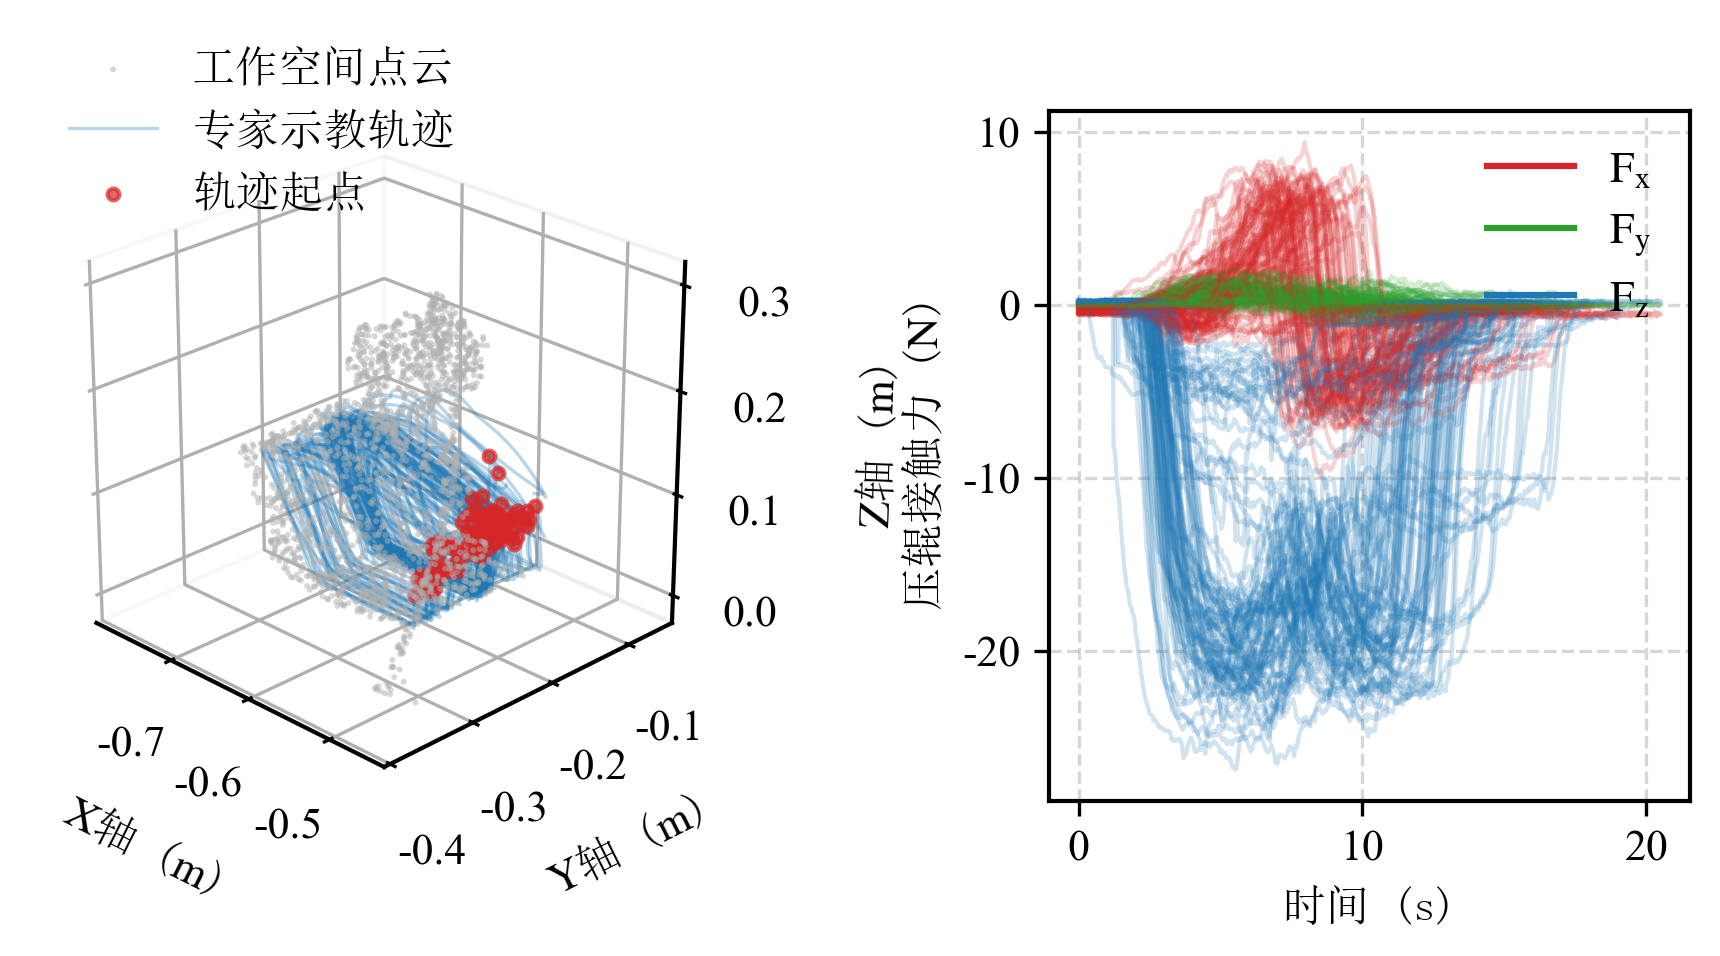

In [16]:
# 运行代码
if __name__ == "__main__":
    file_path = '/home/lgx/Project/AFP/src/il_capture/data/120_mixed_corrected_cleaned_smoothed.hdf5'
    
    print("Loading data...")
    pc_data, trajectories, forces = load_dataset_combined(file_path)
    
    print("Plotting combined academic figure...")
    save_path = "dataset_1x2_combined.pdf" 
    plot_academic_1x2_combined(pc_data, trajectories, forces, save_path=save_path)